# ⚖️ Stage 4: Case Solution Reuse
## Sistem CBR Putusan Pengadilan - Pidana Umum Penggelapan

**Tujuan Notebook ini:**
- Mengimplementasikan fungsi `predict_outcome(query)`
- Membandingkan dua metode prediksi:
  1. **Majority Voting** - setiap kasus mirip memberi 1 suara
  2. **Weighted Similarity Voting** - suara dibobot oleh cosine similarity
- Menampilkan hasil prediksi yang mudah dipahami

**Konsep CBR:**
> Case Reuse adalah proses mengadaptasi solusi dari kasus-kasus mirip yang ditemukan untuk memecahkan kasus baru. Ini adalah tahap akhir dari siklus CBR sebelum evaluasi.

```
Top-K Kasus Mirip
    ↓
Ambil Amar Putusan Masing-Masing
    ↓
┌─────────────────┐    ┌────────────────────────┐
│ Majority Voting │    │ Weighted Voting         │
│ (suara = 1)     │    │ (suara = similarity)    │
└─────────────────┘    └────────────────────────┘
    ↓                          ↓
Prediksi Kategori Hukuman
```

---

In [2]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from retrieval import retrieve
from reuse import majority_voting, weighted_voting, predict_outcome, format_prediction_result

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


## Step 4.1: Load Model dan Data

In [3]:
# Load model yang sudah disimpan di Stage 3
MODEL_DIR = Path('..') / 'models'
CASES_CSV = Path('..') / 'data' / 'processed' / 'cases.csv'

vectorizer   = joblib.load(MODEL_DIR / 'tfidf_vectorizer.pkl')
svm_model    = joblib.load(MODEL_DIR / 'svm_model.pkl')
label_enc    = joblib.load(MODEL_DIR / 'label_encoder.pkl')
tfidf_matrix = joblib.load(MODEL_DIR / 'tfidf_matrix.pkl')

df_cases = pd.read_csv(CASES_CSV, encoding='utf-8-sig')
df_cases = df_cases.fillna({'kategori_hukuman': 'sedang', 'amar_putusan': ''})

print(f'✅ Model berhasil dimuat!')
print(f'Total kasus dalam case base: {len(df_cases)}')
print(f'Kategori: {label_enc.classes_.tolist()}')

✅ Model berhasil dimuat!
Total kasus dalam case base: 106
Kategori: ['berat', 'ringan']


## Step 4.2: Demo Majority Voting

In [4]:
# Query kasus baru
query_demo = """
terdakwa adalah seorang kasir toko yang dipercaya mengelola kas harian.
selama 6 bulan terdakwa secara bertahap mengambil uang dari kas sebesar rp 25 juta.
terdakwa menggunakan uang tersebut untuk keperluan pribadi.
perbuatan terdakwa melanggar pasal 372 kuhp tentang penggelapan.
kerugian perusahaan akibat perbuatan terdakwa sangat besar.
"""

# Step 1: Retrieve top-5 kasus mirip
top_cases = retrieve(query_demo, vectorizer, tfidf_matrix, df_cases, top_k=5)

print('Top 5 Kasus Mirip:')
print('-' * 50)
print(top_cases[['case_id', 'similarity_score', 'kategori_hukuman']].to_string(index=False))

2026-06-18 19:05:30,822 - INFO - Ditemukan 5 kasus paling mirip


Top 5 Kasus Mirip:
--------------------------------------------------
 case_id  similarity_score kategori_hukuman
CASE_027            0.1389           ringan
CASE_099            0.1133            berat
CASE_067            0.1119           ringan
CASE_072            0.1118           ringan
CASE_016            0.1092            berat


In [5]:
# Majority Voting
pred_majority, detail_majority = majority_voting(top_cases)

print('\n🗳️  MAJORITY VOTING')
print('=' * 40)
print('Detail suara tiap kategori:')
for kat, suara in detail_majority.items():
    bar = '█' * suara
    print(f'  {kat:20} : {bar} ({suara} suara)')
print(f'\n  PREDIKSI: {pred_majority.upper()}')

2026-06-18 19:05:30,832 - INFO - Majority Voting: {'ringan': 3, 'berat': 2} -> Prediksi: ringan



🗳️  MAJORITY VOTING
Detail suara tiap kategori:
  ringan               : ███ (3 suara)
  berat                : ██ (2 suara)

  PREDIKSI: RINGAN


## Step 4.3: Demo Weighted Similarity Voting

In [6]:
# Weighted Voting
pred_weighted, detail_weighted = weighted_voting(top_cases)

print('⚖️  WEIGHTED SIMILARITY VOTING')
print('=' * 40)
print('Detail bobot tiap kategori (similarity score dijumlahkan):')
max_weight = max(detail_weighted.values()) if detail_weighted else 1
for kat, bobot in detail_weighted.items():
    bar_len = int((bobot / max_weight) * 20)
    bar = '█' * bar_len
    print(f'  {kat:20} : {bar} ({bobot:.4f})')
print(f'\n  PREDIKSI: {pred_weighted.upper()}')

# Bandingkan
konsisten = pred_majority == pred_weighted
print(f'\n  Konsistensi: {"✅ KONSISTEN" if konsisten else "⚠️  BERBEDA"}')

2026-06-18 19:05:30,840 - INFO - Weighted Voting: {'ringan': 0.3626, 'berat': 0.2225} -> Prediksi: ringan


⚖️  WEIGHTED SIMILARITY VOTING
Detail bobot tiap kategori (similarity score dijumlahkan):
  ringan               : ████████████████████ (0.3626)
  berat                : ████████████ (0.2225)

  PREDIKSI: RINGAN

  Konsistensi: ✅ KONSISTEN


## Step 4.4: Fungsi predict_outcome() - Demo Lengkap

In [7]:
# Gunakan fungsi predict_outcome() yang menggabungkan semuanya
result = predict_outcome(
    query=query_demo,
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix,
    df_cases=df_cases,
    top_k=5
)

# Format dan tampilkan hasil
print(format_prediction_result(result))

2026-06-18 19:05:30,846 - INFO - ==================================================
2026-06-18 19:05:30,846 - INFO - PREDIKSI HASIL KASUS BARU
2026-06-18 19:05:30,846 - INFO - Query: 
terdakwa adalah seorang kasir toko yang dipercaya mengelola kas harian.
selama 6 bulan terdakwa sec...
2026-06-18 19:05:30,847 - INFO - ==================================================
2026-06-18 19:05:30,851 - INFO - Ditemukan 5 kasus paling mirip
2026-06-18 19:05:30,852 - INFO - 
Top 5 kasus mirip berhasil diambil
2026-06-18 19:05:30,852 - INFO - Majority Voting: {'ringan': 3, 'berat': 2} -> Prediksi: ringan
2026-06-18 19:05:30,853 - INFO - Weighted Voting: {'ringan': 0.3626, 'berat': 0.2225} -> Prediksi: ringan
2026-06-18 19:05:30,854 - INFO - 
Hasil Perbandingan:
2026-06-18 19:05:30,854 - INFO -   Majority Voting  : ringan
2026-06-18 19:05:30,854 - INFO -   Weighted Voting  : ringan
2026-06-18 19:05:30,854 - INFO -   Konsisten?       : YA


HASIL PREDIKSI SISTEM CBR

📋 KASUS MIRIP YANG DITEMUKAN:
  1. [CASE_027] Similarity: 0.1389 | Kategori: ringan
  2. [CASE_099] Similarity: 0.1133 | Kategori: berat
  3. [CASE_067] Similarity: 0.1119 | Kategori: ringan
  4. [CASE_072] Similarity: 0.1118 | Kategori: ringan
  5. [CASE_016] Similarity: 0.1092 | Kategori: berat

🗳️  METODE 1 - MAJORITY VOTING:
  Detail Suara : {'ringan': 3, 'berat': 2}
  Prediksi     : ⚖️  RINGAN

⚖️  METODE 2 - WEIGHTED SIMILARITY VOTING:
  Detail Bobot : {'ringan': 0.3626, 'berat': 0.2225}
  Prediksi     : ⚖️  RINGAN

🔍 KONSISTENSI: ✅ YA - Kedua metode sepakat


## Step 4.5: Uji dengan Berbagai Query

In [8]:
# Test beberapa query berbeda
test_queries = [
    {
        "label": "Kasus 1 (Penggelapan Kecil)",
        "query": "terdakwa menggelapkan uang kecil rp 5 juta dari kasir toko melanggar pasal 372 kuhp"
    },
    {
        "label": "Kasus 2 (Penggelapan Besar)",
        "query": "terdakwa direktur keuangan menggelapkan uang perusahaan rp 500 juta selama 2 tahun pasal 374 kuhp jabatan"
    },
    {
        "label": "Kasus 3 (Penggelapan Menengah)",
        "query": "terdakwa bendahara koperasi menggelapkan simpanan anggota sebesar rp 80 juta pasal 374 kuhp"
    },
]

summary_results = []

for test in test_queries:
    res = predict_outcome(
        query=test['query'],
        vectorizer=vectorizer,
        tfidf_matrix=tfidf_matrix,
        df_cases=df_cases,
        top_k=5
    )
    summary_results.append({
        'kasus': test['label'],
        'majority_voting': res['majority_result'],
        'weighted_voting': res['weighted_result'],
        'konsisten': 'Ya' if res['consistent'] else 'Tidak'
    })

summary_df = pd.DataFrame(summary_results)
print('\nRingkasan Prediksi untuk Berbagai Kasus:')
print('=' * 70)
print(summary_df.to_string(index=False))

2026-06-18 19:05:30,862 - INFO - ==================================================
2026-06-18 19:05:30,862 - INFO - PREDIKSI HASIL KASUS BARU
2026-06-18 19:05:30,863 - INFO - Query: terdakwa menggelapkan uang kecil rp 5 juta dari kasir toko melanggar pasal 372 kuhp...
2026-06-18 19:05:30,863 - INFO - ==================================================
2026-06-18 19:05:30,868 - INFO - Ditemukan 5 kasus paling mirip
2026-06-18 19:05:30,869 - INFO - 
Top 5 kasus mirip berhasil diambil
2026-06-18 19:05:30,869 - INFO - Majority Voting: {'ringan': 3, 'berat': 2} -> Prediksi: ringan
2026-06-18 19:05:30,870 - INFO - Weighted Voting: {'ringan': 0.2271, 'berat': 0.1515} -> Prediksi: ringan
2026-06-18 19:05:30,871 - INFO - 
Hasil Perbandingan:
2026-06-18 19:05:30,871 - INFO -   Majority Voting  : ringan
2026-06-18 19:05:30,871 - INFO -   Weighted Voting  : ringan
2026-06-18 19:05:30,872 - INFO -   Konsisten?       : YA
2026-06-18 19:05:30,872 - INFO - =============================================


Ringkasan Prediksi untuk Berbagai Kasus:
                         kasus majority_voting weighted_voting konsisten
   Kasus 1 (Penggelapan Kecil)          ringan          ringan        Ya
   Kasus 2 (Penggelapan Besar)          ringan          ringan        Ya
Kasus 3 (Penggelapan Menengah)           berat          ringan     Tidak


## Step 4.6: Visualisasi Perbandingan Metode

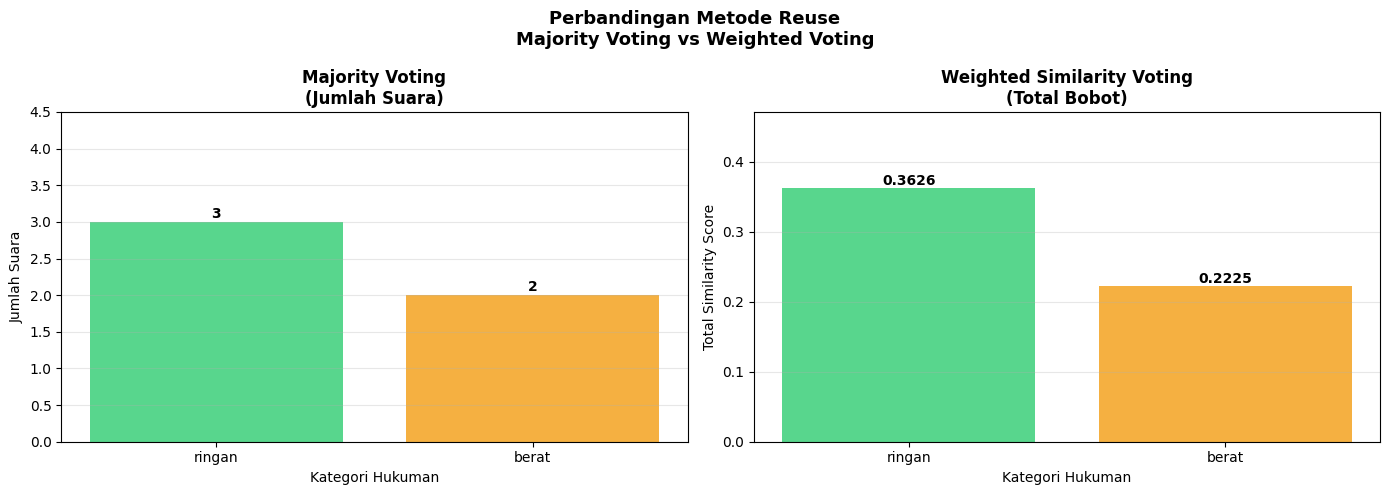

✅ Visualisasi disimpan: outputs/stage4_reuse_comparison.png


In [9]:
# Visualisasi detail voting untuk query_demo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Metode Reuse\nMajority Voting vs Weighted Voting', 
             fontsize=13, fontweight='bold')

# Majority Voting
if detail_majority:
    axes[0].bar(detail_majority.keys(), detail_majority.values(), 
                color=['#2ecc71', '#f39c12', '#e74c3c'][:len(detail_majority)], alpha=0.8)
    axes[0].set_title('Majority Voting\n(Jumlah Suara)', fontweight='bold')
    axes[0].set_xlabel('Kategori Hukuman')
    axes[0].set_ylabel('Jumlah Suara')
    for i, (kat, v) in enumerate(detail_majority.items()):
        axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')
    axes[0].set_ylim(0, max(detail_majority.values()) + 1.5)
    axes[0].grid(alpha=0.3, axis='y')

# Weighted Voting
if detail_weighted:
    axes[1].bar(detail_weighted.keys(), detail_weighted.values(),
                color=['#2ecc71', '#f39c12', '#e74c3c'][:len(detail_weighted)], alpha=0.8)
    axes[1].set_title('Weighted Similarity Voting\n(Total Bobot)', fontweight='bold')
    axes[1].set_xlabel('Kategori Hukuman')
    axes[1].set_ylabel('Total Similarity Score')
    for i, (kat, v) in enumerate(detail_weighted.items()):
        axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
    axes[1].set_ylim(0, max(detail_weighted.values()) * 1.3)
    axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/stage4_reuse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi disimpan: outputs/stage4_reuse_comparison.png')